In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats.mstats import winsorize
from scipy.stats import chi2_contingency

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.svm import SVR

from xgboost import XGBRegressor

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [95]:
# data load
df = pd.read_csv('Data_Polis.csv')

print("Data Polis")
display(df.head()) 

print("\ndata info")
print(df.info())

# data load 2
df2 = pd.read_csv('Data_Klaim.csv')

print("\nData Klaim")
display(df2.head())

print("\ndata info")
print(df2.info())

Data Polis


,Nomor Polis,Plan Code,Gender,Tanggal Lahir,Tanggal Efektif Polis,Domisili
0,POL-0001,M-003,M,19640811,20140603,JAKARTA
1,POL-0002,M-003,M,19710730,20140603,JAKARTA
2,POL-0003,M-001,M,19790821,20160808,JAKARTA
3,POL-0004,M-003,M,20140724,20160811,JAKARTA
4,POL-0005,M-001,F,19810114,20150828,JAKARTA



data info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4096 entries, 0 to 4095
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Nomor Polis            4096 non-null   object
 1   Plan Code              4096 non-null   object
 2   Gender                 4096 non-null   object
 3   Tanggal Lahir          4096 non-null   int64 
 4   Tanggal Efektif Polis  4096 non-null   int64 
 5   Domisili               4096 non-null   object
dtypes: int64(2), object(4)
memory usage: 192.1+ KB
None

Data Klaim


,Claim ID,Nomor Polis,Reimburse/Cashless,Inpatient/Outpatient,ICD Diagnosis,ICD Description,Status Klaim,Tanggal Pembayaran Klaim,Tanggal Pasien Masuk RS,Tanggal Pasien Keluar RS,Nominal Klaim Yang Disetujui,Nominal Biaya RS Yang Terjadi,Lokasi RS
0,C-0001-M,POL-0176,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,PAID,2024-07-08,2024-05-27,2024-05-27,28093653.0,6.143948e+06,Singapore
1,C-0002-M,POL-3288,R,OP,C34,MALIGNANT NEOPLASM OF BRONCHUS AND LUNG,PAID,2024-08-06,2024-07-15,2024-07-15,80987278.0,8.230952e+07,Malaysia
2,C-0003-M,POL-1786,R,OP,C18.9,"MALIGNANT NEOPLASM, COLON, UNSPECIFIED",PAID,2024-10-17,2024-05-16,2024-05-16,183047130.0,1.928599e+08,Singapore
3,C-0004-M,POL-1786,R,OP,C34,MALIGNANT NEOPLASM OF BRONCHUS AND LUNG,PAID,2024-09-03,2024-07-18,2024-07-18,191424386.0,1.914244e+08,Singapore
4,C-0005-M,POL-2778,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,PAID,NaN,2024-06-06,2024-06-06,138936357.0,1.389364e+08,Singapore



data info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4627 entries, 0 to 4626
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Claim ID                       4627 non-null   object 
 1   Nomor Polis                    4627 non-null   object 
 2   Reimburse/Cashless             4627 non-null   object 
 3   Inpatient/Outpatient           4590 non-null   object 
 4   ICD Diagnosis                  4621 non-null   object 
 5   ICD Description                4621 non-null   object 
 6   Status Klaim                   4627 non-null   object 
 7   Tanggal Pembayaran Klaim       4590 non-null   object 
 8   Tanggal Pasien Masuk RS        4627 non-null   object 
 9   Tanggal Pasien Keluar RS       4627 non-null   object 
 10  Nominal Klaim Yang Disetujui   4627 non-null   float64
 11  Nominal Biaya RS Yang Terjadi  4627 non-null   float64
 12  Lokasi RS                      4620 n

In [96]:
df['Tanggal Lahir'] = pd.to_datetime(df['Tanggal Lahir'], format='%Y%m%d')
df['Tanggal Efektif Polis'] = pd.to_datetime(df['Tanggal Efektif Polis'], format='%Y%m%d')

df2['Tanggal Pembayaran Klaim'] = pd.to_datetime(df2['Tanggal Pembayaran Klaim'])
df2['Tanggal Pasien Masuk RS'] = pd.to_datetime(df2['Tanggal Pasien Masuk RS'])
df2['Tanggal Pasien Keluar RS'] = pd.to_datetime(df2['Tanggal Pasien Keluar RS'])

df.dtypes
df2.dtypes

Claim ID                                 object
Nomor Polis                              object
Reimburse/Cashless                       object
Inpatient/Outpatient                     object
ICD Diagnosis                            object
ICD Description                          object
Status Klaim                             object
Tanggal Pembayaran Klaim         datetime64[ns]
Tanggal Pasien Masuk RS          datetime64[ns]
Tanggal Pasien Keluar RS         datetime64[ns]
Nominal Klaim Yang Disetujui            float64
Nominal Biaya RS Yang Terjadi           float64
Lokasi RS                                object
dtype: object


Missing value Data Polis
Series([], dtype: int64)


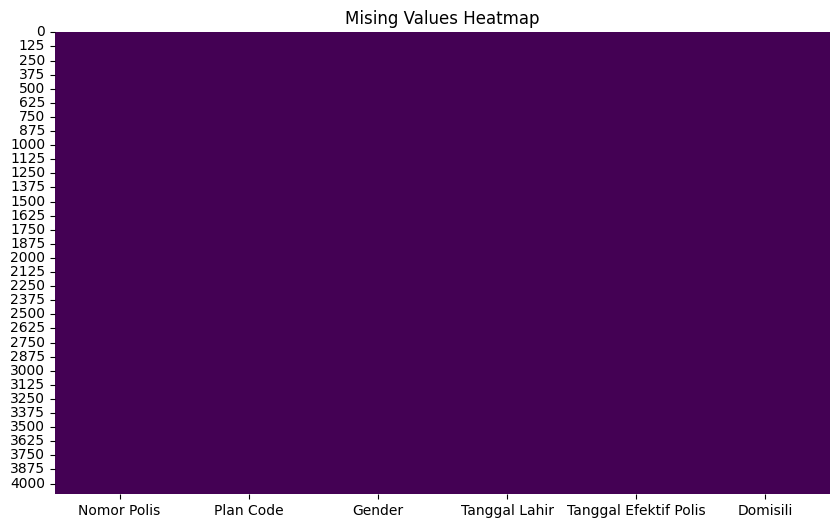


Missing value Data Klaim
Inpatient/Outpatient        37
ICD Diagnosis                6
ICD Description              6
Tanggal Pembayaran Klaim    37
Lokasi RS                    7
dtype: int64


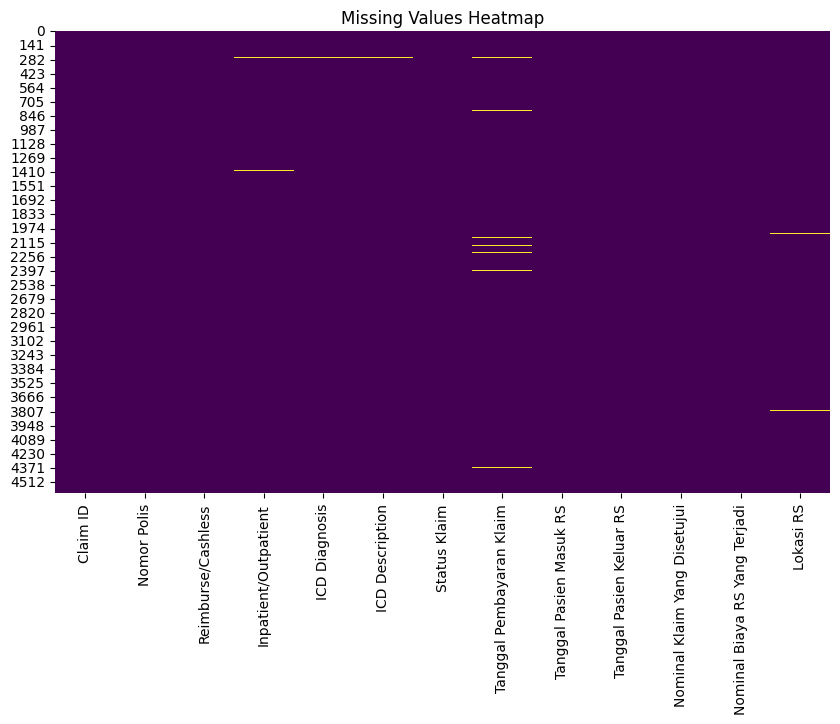

In [97]:
# missing value data polis
print("\nMissing value Data Polis")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0]) 

plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Mising Values Heatmap')
plt.show()

# missing value data klaim
print("\nMissing value Data Klaim")
missing_values = df2.isnull().sum()
print(missing_values[missing_values > 0]) 

plt.figure(figsize=(10, 6))
sns.heatmap(df2.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

In [98]:
df['Nomor Polis'] = df['Nomor Polis'].str.strip()
df2['Nomor Polis'] = df2['Nomor Polis'].str.strip()

df_final = pd.merge(df, df2, on='Nomor Polis', how='left')

print(f"Jumlah baris df_polis: {len(df)}")
print(f"Jumlah baris df_klaim: {len(df2)}")
print(f"Jumlah baris hasil merge: {len(df_final)}")

display(df_final.head())

Jumlah baris df_polis: 4096
Jumlah baris df_klaim: 4627
Jumlah baris hasil merge: 7513


,Nomor Polis,Plan Code,Gender,Tanggal Lahir,Tanggal Efektif Polis,Domisili,Claim ID,Reimburse/Cashless,Inpatient/Outpatient,ICD Diagnosis,ICD Description,Status Klaim,Tanggal Pembayaran Klaim,Tanggal Pasien Masuk RS,Tanggal Pasien Keluar RS,Nominal Klaim Yang Disetujui,Nominal Biaya RS Yang Terjadi,Lokasi RS
0,POL-0001,M-003,M,1964-08-11,2014-06-03,JAKARTA,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaT,NaN,NaN,NaN
1,POL-0002,M-003,M,1971-07-30,2014-06-03,JAKARTA,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaT,NaN,NaN,NaN
2,POL-0003,M-001,M,1979-08-21,2016-08-08,JAKARTA,C-3535-M,C,IP,S83.2,"TEAR OF MENISCUS, CURRENT",PAID,2024-10-31,2024-09-09,2024-09-10,14138163.0,14138163.0,Indonesia
3,POL-0004,M-003,M,2014-07-24,2016-08-11,JAKARTA,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaT,NaN,NaN,NaN
4,POL-0005,M-001,F,1981-01-14,2015-08-28,JAKARTA,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaT,NaN,NaN,NaN


In [99]:
cols_to_zero = ['Nominal Klaim Yang Disetujui', 'Nominal Biaya RS Yang Terjadi']
df_final[cols_to_zero] = df_final[cols_to_zero].fillna(0)

df_final['is_claim'] = df_final['Claim ID'].notnull().astype(int)

cat_cols = [
    'Claim ID', 'Reimburse/Cashless', 'Inpatient/Outpatient', 
    'ICD Diagnosis', 'ICD Description', 'Lokasi RS', 'Status Klaim'
]

for col in cat_cols:
    df_final.loc[df_final['is_claim'] == 0, col] = 'No Claim'
    df_final[col] = df_final[col].fillna('Unknown')

display(df_final.head())

,Nomor Polis,Plan Code,Gender,Tanggal Lahir,Tanggal Efektif Polis,Domisili,Claim ID,Reimburse/Cashless,Inpatient/Outpatient,ICD Diagnosis,ICD Description,Status Klaim,Tanggal Pembayaran Klaim,Tanggal Pasien Masuk RS,Tanggal Pasien Keluar RS,Nominal Klaim Yang Disetujui,Nominal Biaya RS Yang Terjadi,Lokasi RS,is_claim
0,POL-0001,M-003,M,1964-08-11,2014-06-03,JAKARTA,No Claim,No Claim,No Claim,No Claim,No Claim,No Claim,NaT,NaT,NaT,0.0,0.0,No Claim,0
1,POL-0002,M-003,M,1971-07-30,2014-06-03,JAKARTA,No Claim,No Claim,No Claim,No Claim,No Claim,No Claim,NaT,NaT,NaT,0.0,0.0,No Claim,0
2,POL-0003,M-001,M,1979-08-21,2016-08-08,JAKARTA,C-3535-M,C,IP,S83.2,"TEAR OF MENISCUS, CURRENT",PAID,2024-10-31,2024-09-09,2024-09-10,14138163.0,14138163.0,Indonesia,1
3,POL-0004,M-003,M,2014-07-24,2016-08-11,JAKARTA,No Claim,No Claim,No Claim,No Claim,No Claim,No Claim,NaT,NaT,NaT,0.0,0.0,No Claim,0
4,POL-0005,M-001,F,1981-01-14,2015-08-28,JAKARTA,No Claim,No Claim,No Claim,No Claim,No Claim,No Claim,NaT,NaT,NaT,0.0,0.0,No Claim,0


In [100]:
# Separasi Dataset
# Cluster Check untuk severity
cluster_check = df_final[df_final['Inpatient/Outpatient'].isnull() & df_final['Tanggal Pembayaran Klaim'].isnull()]
print(f"Jumlah baris dalam cluster masalah: {len(cluster_check)}")

# Dataset Severity (hanya klaim yang terjadi)
df_severity = df_final[df_final['is_claim'] == 1].copy()

# Bersihkan cluster 37 baris di data severity karena akan merusak akurasi fitur medis
df_severity = df_severity.dropna(subset=['Inpatient/Outpatient', 'ICD Diagnosis'])

# Dataset FREKUENSI 
df_frequency = df_final.copy()

print(f"Ukuran Data Severity: {df_severity.shape}")
print(f"Ukuran Data Frequency: {df_frequency.shape}")

Jumlah baris dalam cluster masalah: 0
Ukuran Data Severity: (4627, 19)
Ukuran Data Frequency: (7513, 19)


Baris sebelum drop usia negatif : 4627
Baris setelah drop usia negatif : 4627

Statistik Usia Severity:
count    4627.000000
mean       59.346490
std        12.567030
min         6.795346
25%        51.438741
50%        59.947981
75%        68.939083
max        90.324435
Name: Usia_Saat_Klaim, dtype: float64


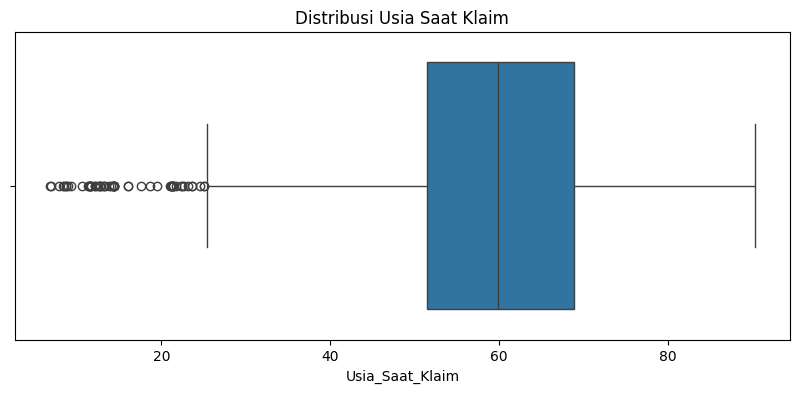

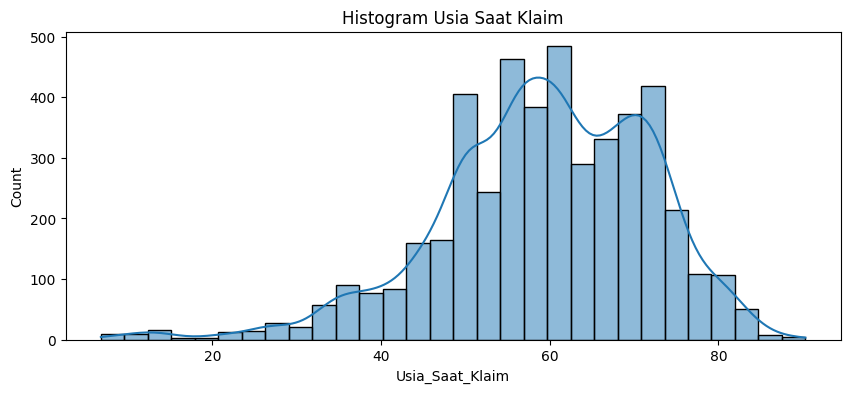

In [101]:
# Feature Engineering & Data Validation AGE)

# Hitung usia
df_severity['Usia_Saat_Klaim'] = (
    (df_severity['Tanggal Pasien Masuk RS'] - df_severity['Tanggal Lahir']).dt.days / 365.25
)

# handle usia negatif (data error)
before_rows = len(df_severity)
df_severity = df_severity[df_severity['Usia_Saat_Klaim'] >= 0].copy()
after_rows = len(df_severity)

print(f"Baris sebelum drop usia negatif : {before_rows}")
print(f"Baris setelah drop usia negatif : {after_rows}")

# Cap outlier biologis menggunakan batas logis 100 tahun
upper_cap = 100
outlier_count = (df_severity['Usia_Saat_Klaim'] > upper_cap).sum()

if outlier_count > 0:
    print(f"Ditemukan {outlier_count} usia > {upper_cap}. Akan di-cap.")
    df_severity.loc[
        df_severity['Usia_Saat_Klaim'] > upper_cap,
        'Usia_Saat_Klaim'
    ] = upper_cap

# BINNING USIA

age_bins = [0, 12, 18, 45, 65, 100]
age_labels = ['Anak', 'Remaja', 'Dewasa', 'Lansia_Awal', 'Lansia_Akhir']

df_severity['Kategori_Usia'] = pd.cut(
    df_severity['Usia_Saat_Klaim'],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)

# USIA NASABAH (FREQUENCY)

ref_date = df_frequency['Tanggal Efektif Polis'].max()

df_frequency['Tanggal Lahir'] = pd.to_datetime(df_frequency['Tanggal Lahir'])

df_frequency['Usia_Nasabah'] = (
    (ref_date - df_frequency['Tanggal Lahir']).dt.days / 365.25
)

# Handle usia negatif 
df_frequency = df_frequency[df_frequency['Usia_Nasabah'] >= 0].copy()

# VISUALISASI
print("\nStatistik Usia Severity:")
print(df_severity['Usia_Saat_Klaim'].describe())

plt.figure(figsize=(10,4))
sns.boxplot(x=df_severity['Usia_Saat_Klaim'])
plt.title('Distribusi Usia Saat Klaim')
plt.show()

plt.figure(figsize=(10,4))
sns.histplot(df_severity['Usia_Saat_Klaim'], bins=30, kde=True)
plt.title('Histogram Usia Saat Klaim')
plt.show()

In [102]:
# Hitung Length of Stay & Bersihkan Error

# Hitung LOS
df_severity['Lama_Inap'] = (
    df_severity['Tanggal Pasien Keluar RS'] -
    df_severity['Tanggal Pasien Masuk RS']
).dt.days

# Hapus error tanggal (keluar < masuk)
before_rows = len(df_severity)
df_severity = df_severity[df_severity['Lama_Inap'] >= 0].copy()
after_rows = len(df_severity)

print(f"Baris sebelum : {before_rows}")
print(f"Baris setelah : {after_rows}")

print(df_severity['Lama_Inap'].describe())

Baris sebelum : 4627
Baris setelah : 4627
count    4627.000000
mean        1.264102
std         2.930572
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max        54.000000
Name: Lama_Inap, dtype: float64


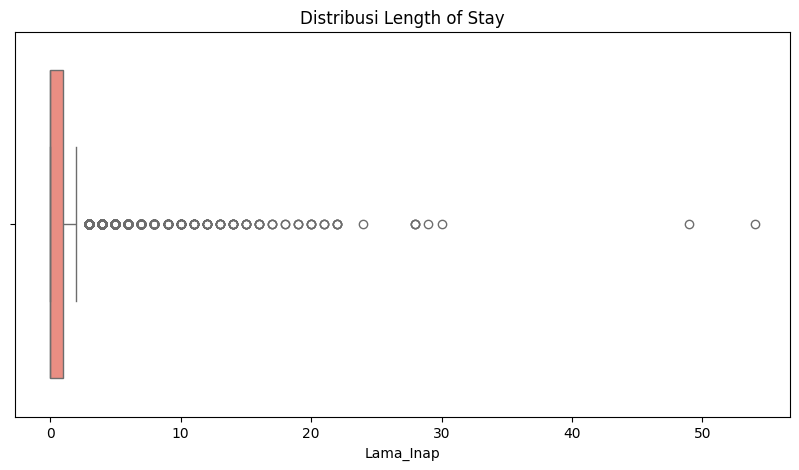

Detail LOS 54 Hari:


,Nomor Polis,ICD Description,Nominal Biaya RS Yang Terjadi,Inpatient/Outpatient
1368,POL-0830,"MALIGNANT NEOPLASM, BRONCHUS OR LUNG, UNSPECIFIED",1.465628e+09,IP


In [103]:
# Cek Outlier 54 Hari

plt.figure(figsize=(10,5))
sns.boxplot(x=df_severity['Lama_Inap'], color='salmon')
plt.title('Distribusi Length of Stay')
plt.show()

# Investigasi LOS 54 hari
outlier_54 = df_severity[df_severity['Lama_Inap'] == 54]

print("Detail LOS 54 Hari:")
display(outlier_54[['Nomor Polis',
                    'ICD Description',
                    'Nominal Biaya RS Yang Terjadi',
                    'Inpatient/Outpatient']])

In [104]:
# Feature Final LOS

# Dummy outpatient
df_severity['Is_Outpatient'] = (df_severity['Lama_Inap'] == 0).astype(int)

# Adjusted LOS (untuk hindari log(0))
df_severity['Lama_Inap_Adj'] = df_severity['Lama_Inap'] + 1

# Optional: Capping 99% (tidak akan menghapus 54 jika masih dalam batas)
los_cap = df_severity['Lama_Inap'].quantile(0.99)

df_severity['Lama_Inap_Capped'] = np.where(
    df_severity['Lama_Inap'] > los_cap,
    los_cap,
    df_severity['Lama_Inap']
)

print(f"99th percentile: {los_cap}")

print("\nStatistik Final:")
print(df_severity[['Lama_Inap','Lama_Inap_Capped']].describe())

99th percentile: 13.0

Statistik Final:
         Lama_Inap  Lama_Inap_Capped
count  4627.000000       4627.000000
mean      1.264102          1.192998
std       2.930572          2.401121
min       0.000000          0.000000
25%       0.000000          0.000000
50%       0.000000          0.000000
75%       1.000000          1.000000
max      54.000000         13.000000


In [105]:
# Feature Engineering (SEASONALITY) 

# 1 ENSURE DATETIME
df_severity['Tanggal Pasien Masuk RS'] = pd.to_datetime(
    df_severity['Tanggal Pasien Masuk RS']
)

# 2 BASIC TIME FEATURES
df_severity['Tahun_Masuk'] = df_severity['Tanggal Pasien Masuk RS'].dt.year
df_severity['Bulan_Masuk'] = df_severity['Tanggal Pasien Masuk RS'].dt.month
df_severity['Hari_Masuk'] = df_severity['Tanggal Pasien Masuk RS'].dt.dayofweek
df_severity['Tanggal'] = df_severity['Tanggal Pasien Masuk RS'].dt.day

# 3 PERIODE BULANAN 
df_severity['Periode_Klaim'] = (
    df_severity['Tanggal Pasien Masuk RS'].dt.to_period('M')
)

# 4 QUARTER FEATURE 
df_severity['Quarter'] = df_severity['Tanggal Pasien Masuk RS'].dt.quarter

# 5 WEEKEND FLAG 
df_severity['Is_Weekend'] = (
    df_severity['Hari_Masuk'].isin([5,6])
).astype(int)

# 6 CYCLICAL ENCODING BULAN 
df_severity['Bulan_sin'] = np.sin(
    2 * np.pi * df_severity['Bulan_Masuk'] / 12
)

df_severity['Bulan_cos'] = np.cos(
    2 * np.pi * df_severity['Bulan_Masuk'] / 12
)

# 7 VALIDASI 
print("Fitur seasonality berhasil dibuat.\n")

display(
    df_severity[[
        'Periode_Klaim',
        'Tahun_Masuk',
        'Bulan_Masuk',
        'Quarter',
        'Hari_Masuk',
        'Is_Weekend'
    ]].head()
)

Fitur seasonality berhasil dibuat.



,Periode_Klaim,Tahun_Masuk,Bulan_Masuk,Quarter,Hari_Masuk,Is_Weekend
2,2024-09,2024,9,3,0,0
5,2024-08,2024,8,3,4,0
6,2024-10,2024,10,4,2,0
10,2024-01,2024,1,1,4,0
11,2024-01,2024,1,1,3,0


In [106]:
# CELL REPORT: Claim Portfolio Summary 

# 1 Basic Metrics
total_claim = len(df_severity)
unique_policy_claim = df_severity['Nomor Polis'].nunique()
total_policy = df_frequency['Nomor Polis'].nunique()

avg_claim_per_policy = total_claim / unique_policy_claim

percentage_with_claim = (unique_policy_claim / total_policy) * 100
percentage_without_claim = ((total_policy - unique_policy_claim) / total_policy) * 100

# 2 DataFrame Report
df_claim_report = pd.DataFrame({
    'Total_Polis_Portfolio': [total_policy],
    'Total_Klaim': [total_claim],
    'Polis_Pernah_Klaim': [unique_policy_claim],
    'Polis_Tidak_Pernah_Klaim': [total_policy - unique_policy_claim],
    'Rata2_Klaim_per_Polis_Klaim': [round(avg_claim_per_policy, 2)],
    'Persentase_Polis_Pernah_Klaim (%)': [round(percentage_with_claim, 2)],
    'Persentase_Polis_Tidak_Klaim (%)': [round(percentage_without_claim, 2)]
})

display(df_claim_report)

,Total_Polis_Portfolio,Total_Klaim,Polis_Pernah_Klaim,Polis_Tidak_Pernah_Klaim,Rata2_Klaim_per_Polis_Klaim,Persentase_Polis_Pernah_Klaim (%),Persentase_Polis_Tidak_Klaim (%)
0,4096,4627,1210,2886,3.82,29.54,70.46


In [107]:


# ================================
# CLEAN RAW DATA
# ================================

df_severity.columns = df_severity.columns.str.strip()

# Aggregasi bulanan
df_monthly = df_severity.groupby('Periode_Klaim').agg(
    Claim_Frequency=('Claim ID', 'count'),
    Total_Claim=('Nominal Klaim Yang Disetujui', 'sum')
).reset_index()

# Datetime conversion
df_monthly['Periode_Klaim'] = pd.to_datetime(
    df_monthly['Periode_Klaim'].astype(str)
)
df_monthly = df_monthly.sort_values('Periode_Klaim').reset_index(drop=True)

# ================================
# PAD MISSING MONTHS (SAFE VERSION)
# ================================

all_months = pd.date_range(
    start=df_monthly['Periode_Klaim'].min(),
    end=df_monthly['Periode_Klaim'].max(),
    freq='MS'
)

df_monthly = (
    df_monthly.set_index('Periode_Klaim')
    .reindex(all_months)
    .ffill()   # 🔥 lebih aman daripada fillna(0)
    .reset_index()
    .rename(columns={'index': 'Periode_Klaim'})
)

# ================================
# TIME FEATURES
# ================================

df_monthly['Time_Index'] = range(len(df_monthly))

# Trend signal dinonaktifkan karena tidak informatif
df_monthly['Trend_Signal'] = 0

# ================================
# CYCLICAL SEASONALITY (WAJIB ADA)
# ================================

if 'Bulan_sin' not in df_monthly.columns:
    df_monthly['Bulan'] = df_monthly['Periode_Klaim'].dt.month

    df_monthly['Bulan_sin'] = np.sin(
        2 * np.pi * df_monthly['Bulan'] / 12
    )

    df_monthly['Bulan_cos'] = np.cos(
        2 * np.pi * df_monthly['Bulan'] / 12
    )

# ================================
# FINAL LAG STRUCTURE
# ================================

df_monthly['Freq_Lag_1'] = df_monthly['Claim_Frequency'].shift(1)
df_monthly['Freq_Lag_3'] = df_monthly['Claim_Frequency'].shift(3)

df_monthly['Total_Lag_1'] = df_monthly['Total_Claim'].shift(1)
df_monthly['Total_Lag_3'] = df_monthly['Total_Claim'].shift(3)

# Moving Average Stabilizer
df_monthly['Freq_MA_3'] = df_monthly['Claim_Frequency'].shift(1).rolling(3).mean()
df_monthly['Total_MA_3'] = df_monthly['Total_Claim'].shift(1).rolling(3).mean()
# ================================
# CREATE CLAIM SEVERITY
# ================================

df_monthly['Claim_Severity'] = np.where(
    df_monthly['Claim_Frequency'] > 0,
    df_monthly['Total_Claim'] / df_monthly['Claim_Frequency'],
    0
)
# ================================
# FINAL CLEANING
# ================================

df_monthly_final = df_monthly.dropna().reset_index(drop=True)

print("Final Feature Engineering Shape:", df_monthly_final.shape)
display(df_monthly_final.head())

Final Feature Engineering Shape: (16, 15)


,Periode_Klaim,Claim_Frequency,Total_Claim,Time_Index,Trend_Signal,Bulan,Bulan_sin,Bulan_cos,Freq_Lag_1,Freq_Lag_3,Total_Lag_1,Total_Lag_3,Freq_MA_3,Total_MA_3,Claim_Severity
0,2024-04-01,239,1.144106e+10,3,0,4,8.660254e-01,-0.500000,278.0,302.0,1.431126e+10,2.026098e+10,262.666667,1.614396e+10,4.787056e+07
1,2024-05-01,263,1.221146e+10,4,0,5,5.000000e-01,-0.866025,239.0,208.0,1.144106e+10,1.385965e+10,241.666667,1.320399e+10,4.643141e+07
2,2024-06-01,225,1.212517e+10,5,0,6,1.224647e-16,-1.000000,263.0,278.0,1.221146e+10,1.431126e+10,260.000000,1.265459e+10,5.388963e+07
3,2024-07-01,257,1.497052e+10,6,0,7,-5.000000e-01,-0.866025,225.0,239.0,1.212517e+10,1.144106e+10,242.333333,1.192590e+10,5.825104e+07
4,2024-08-01,228,1.351294e+10,7,0,8,-8.660254e-01,-0.500000,257.0,263.0,1.497052e+10,1.221146e+10,248.333333,1.310238e+10,5.926726e+07


In [108]:
print (df_monthly.head())

# Cek tanggal awal dan akhir di data bulanan
print("--- Rentang Waktu Data Bulanan ---")
print("Tanggal Terawal:", df_monthly['Periode_Klaim'].min())
print("Tanggal Terbaru:", df_monthly['Periode_Klaim'].max())

# Cek jumlah bulan yang tersedia
total_bulan = len(df_monthly)
print(f"Total Observasi: {total_bulan} bulan")

  Periode_Klaim  Claim_Frequency   Total_Claim  Time_Index  Trend_Signal  \
0    2024-01-01              302  2.026098e+10           0             0   
1    2024-02-01              208  1.385965e+10           1             0   
2    2024-03-01              278  1.431126e+10           2             0   
3    2024-04-01              239  1.144106e+10           3             0   
4    2024-05-01              263  1.221146e+10           4             0   

   Bulan  Bulan_sin     Bulan_cos  Freq_Lag_1  Freq_Lag_3   Total_Lag_1  \
0      1   0.500000  8.660254e-01         NaN         NaN           NaN   
1      2   0.866025  5.000000e-01       302.0         NaN  2.026098e+10   
2      3   1.000000  6.123234e-17       208.0         NaN  1.385965e+10   
3      4   0.866025 -5.000000e-01       278.0       302.0  1.431126e+10   
4      5   0.500000 -8.660254e-01       239.0       208.0  1.144106e+10   

    Total_Lag_3   Freq_MA_3    Total_MA_3  Claim_Severity  
0           NaN         NaN     

In [109]:
print(df_monthly['Claim_Severity'].skew())

0.6670998442694679


In [110]:
df_monthly['Claim_Severity'].describe()

count    1.900000e+01
mean     5.507353e+07
std      7.440240e+06
min      4.449250e+07
25%      5.067090e+07
50%      5.367427e+07
75%      5.911469e+07
max      7.105911e+07
Name: Claim_Severity, dtype: float64

In [111]:
df_monthly['Log_Severity'] = np.log1p(df_monthly['Claim_Severity'])

In [112]:
print(df_monthly['Log_Severity'].skew())

0.42289559513197145


In [113]:
# ================================
# FEATURE LIST FINAL VERSION
# ================================

features = [
    'Bulan_sin',
    'Bulan_cos',

    'Freq_Lag_1',
    'Freq_Lag_3',

    'Total_Lag_1',
    'Total_Lag_3',

    'Freq_MA_3',
    'Total_MA_3',

    'Time_Index'
]

print("Features Updated")
print(features)

# ================================
# TRAIN SEVERITY MODEL (LOG TARGET)
# ================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
import numpy as np

def train_severity_model(df, feature_cols):

    X = df[feature_cols]
    y_log = df['Log_Severity']

    # Model pipeline
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('xgb', XGBRegressor(
            n_estimators=200,
            max_depth=2,
            learning_rate=0.03,
            subsample=0.8,
            colsample_bytree=0.8,
            colsample_bylevel=0.8,
            random_state=42,
            objective='reg:squarederror'
        ))
    ])

    # Training
    model.fit(X, y_log)

    # Prediction (log scale)
    pred_log = model.predict(X)

    # Inverse transform ke scale asli
    pred_original = np.expm1(pred_log)
    y_original = np.expm1(y_log)

    # Evaluation RMSE (real scale)
    rmse = np.sqrt(mean_squared_error(y_original, pred_original))

    print("\n=== Severity Model Summary ===")
    print("Severity RMSE:", rmse)

    return model, rmse

Features Updated
['Bulan_sin', 'Bulan_cos', 'Freq_Lag_1', 'Freq_Lag_3', 'Total_Lag_1', 'Total_Lag_3', 'Freq_MA_3', 'Total_MA_3', 'Time_Index']


In [114]:
def train_best_model(df, target_col):

    X = df[features]
    y = df[target_col]

    # Imputer + scaler pipeline (stable version)
    pipeline_xgb = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('xgb', XGBRegressor(
            n_estimators=200,
            max_depth=2,
            learning_rate=0.03,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            objective='reg:squarederror'
        ))
    ])

    pipeline_svr = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('svr', SVR(kernel='rbf', C=30, epsilon=0.1))
    ])

    pipeline_xgb.fit(X, y)
    pipeline_svr.fit(X, y)

    pred_xgb = pipeline_xgb.predict(X)
    pred_svr = pipeline_svr.predict(X)

    rmse_xgb = np.sqrt(mean_squared_error(y, pred_xgb))
    rmse_svr = np.sqrt(mean_squared_error(y, pred_svr))

    if rmse_xgb <= rmse_svr:
        return pipeline_xgb, None, "xgb", rmse_xgb
    else:
        return pipeline_svr, None, "svr", rmse_svr

In [115]:
# ================================
# SORT TIME SERIES
# ================================

df_monthly = df_monthly.sort_values('Periode_Klaim').reset_index(drop=True)

# FIX COPY BUG
train_df = df_monthly[df_monthly['Periode_Klaim'] <= '2025-07-01'].copy()

# ================================
# TRAINING MODELS
# ================================

print("Training Frequency Model...")

model_freq, _, type_freq, rmse_freq = train_best_model(
    train_df,
    'Claim_Frequency'
)

print("Training Severity Model (Log Transformed)...")

# Pastikan target severity log sudah ada
if 'Log_Severity' not in train_df.columns:
    train_df['Log_Severity'] = np.log1p(train_df['Claim_Severity'])

model_sev, _, type_sev, rmse_sev = train_best_model(
    train_df,
    'Log_Severity'
)

# ================================
# MODEL SUMMARY
# ================================

print("\n=== MODEL SUMMARY ===")
print("Frequency Model :", type_freq, "RMSE:", rmse_freq)
print("Severity Model  :", type_sev, "RMSE:", rmse_sev)

Training Frequency Model...


Training Severity Model (Log Transformed)...

=== MODEL SUMMARY ===
Frequency Model : xgb RMSE: 4.692566028713703
Severity Model  : xgb RMSE: 0.02679280291649291


In [116]:
from sklearn.metrics import mean_squared_error
import numpy as np

# ================================
# SIMPLE TIME SERIES VALIDATION
# ================================

# Split data (last 3 months as validation)
train = train_df.iloc[:-3]
val = train_df.iloc[-3:]

# Feature set
X_train = train[features]
y_train_freq = train['Claim_Frequency']
y_train_sev = train['Log_Severity']

X_val = val[features]
y_val_freq = val['Claim_Frequency']
y_val_sev = val['Log_Severity']

# ================================
# Frequency RMSE
# ================================

pred_train_freq = model_freq.predict(X_train)
pred_val_freq = model_freq.predict(X_val)

rmse_freq_train = np.sqrt(mean_squared_error(y_train_freq, pred_train_freq))
rmse_freq_val = np.sqrt(mean_squared_error(y_val_freq, pred_val_freq))

# ================================
# Severity RMSE (inverse transform dulu)
# ================================

pred_train_sev_log = model_sev.predict(X_train)
pred_val_sev_log = model_sev.predict(X_val)

# Convert back to original scale
y_train_sev_real = np.expm1(y_train_sev)
y_val_sev_real = np.expm1(y_val_sev)

pred_train_sev_real = np.expm1(pred_train_sev_log)
pred_val_sev_real = np.expm1(pred_val_sev_log)

rmse_sev_train = np.sqrt(mean_squared_error(
    y_train_sev_real,
    pred_train_sev_real
))

rmse_sev_val = np.sqrt(mean_squared_error(
    y_val_sev_real,
    pred_val_sev_real
))

# ================================
# RESULT
# ================================

print("=== Frequency RMSE ===")
print("Train :", rmse_freq_train)
print("Val   :", rmse_freq_val)

print("\n=== Severity RMSE ===")
print("Train :", rmse_sev_train)
print("Val   :", rmse_sev_val)

=== Frequency RMSE ===
Train : 4.880602820325631
Val   : 3.5241450848974334

=== Severity RMSE ===
Train : 1578696.321118618
Val   : 927918.6295518106


In [117]:
def blended_forecast(model, X, y_history):

    # Model prediction
    pred_log = model.predict(X)
    pred_model = np.expm1(pred_log)

    # Moving average baseline forecast
    sma_forecast = y_history.rolling(3).mean().iloc[-len(pred_model):].values

    # Blending (tuned weight)
    final_pred = 0.7 * pred_model + 0.3 * sma_forecast

    return final_pred

In [118]:
future_steps = 5
temp_df = train_df.copy()

alpha_memory = 0.6
alpha_model = 0.4

future_freq = []
future_sev = []
future_total = []

for i in range(future_steps):

    # ================================
    # FEATURE BUILDING
    # ================================

    X_next = pd.DataFrame([{
        'Bulan_sin': temp_df['Bulan_sin'].iloc[-1],
        'Bulan_cos': temp_df['Bulan_cos'].iloc[-1],

        'Freq_Lag_1': temp_df['Claim_Frequency'].iloc[-1],
        'Freq_Lag_3': temp_df['Claim_Frequency'].iloc[-3:].mean(),

        'Total_Lag_1': temp_df['Total_Claim'].iloc[-1],
        'Total_Lag_3': temp_df['Total_Claim'].iloc[-3:].mean(),

        'Freq_MA_3': temp_df['Claim_Frequency'].iloc[-3:].mean(),
        'Total_MA_3': temp_df['Total_Claim'].iloc[-3:].mean(),

        'Time_Index': temp_df['Time_Index'].iloc[-1] + 1
    }])[features]

    # ================================
    # FREQUENCY FORECAST
    # ================================

    raw_freq = model_freq.predict(X_next)[0]
    hist_freq = temp_df['Claim_Frequency'].iloc[-3:].mean()

    p_freq = alpha_model * max(0, raw_freq) + \
             alpha_memory * hist_freq

    # ================================
    # SEVERITY FORECAST (LOG MODEL)
    # ================================

    raw_sev_log = model_sev.predict(X_next)[0]
    raw_sev = np.expm1(raw_sev_log)

    hist_sev = temp_df['Claim_Severity'].iloc[-3:].mean()

    p_sev = alpha_model * max(0, raw_sev) + \
            alpha_memory * hist_sev

    # ================================
    # TOTAL FORECAST (ACTUARIAL CONSISTENCY)
    # ================================

    p_total = p_freq * p_sev

    # Stability clamp
    p_freq = max(0, p_freq)
    p_sev = max(0, p_sev)
    p_total = max(0, p_total)

    # ================================
    # STORE RESULT
    # ================================

    future_freq.append(p_freq)
    future_sev.append(p_sev)
    future_total.append(p_total)

    new_row = {
        'Periode_Klaim': temp_df['Periode_Klaim'].max() + pd.DateOffset(months=1),
        'Claim_Frequency': p_freq,
        'Claim_Severity': p_sev,
        'Total_Claim': p_total,
        'Time_Index': X_next['Time_Index'].values[0]
    }

    temp_df = pd.concat([temp_df, pd.DataFrame([new_row])], ignore_index=True)

In [119]:
# ================================
# GENERATE SUBMISSION FILE
# ================================

df_sub_data = temp_df[temp_df['Periode_Klaim'].dt.year == 2025].copy()

submission = pd.read_csv('sample_submission.csv')

for _, row in df_sub_data.iterrows():

    month_str = row['Periode_Klaim'].strftime('%Y_%m')

    # Frequency
    submission.loc[
        submission['id'] == f"{month_str}_Claim_Frequency",
        'value'
    ] = max(0, row['Claim_Frequency'])

    # Severity
    submission.loc[
        submission['id'] == f"{month_str}_Claim_Severity",
        'value'
    ] = max(0, row['Claim_Severity'])

    # Total Claim
    submission.loc[
        submission['id'] == f"{month_str}_Total_Claim",
        'value'
    ] = max(0, row['Total_Claim'])

# Save submission file
submission.to_csv('submission_XG.csv', index=False)

print("File 'submission_final.csv' siap disubmit!")

File 'submission_final.csv' siap disubmit!


C:\Users\Ababil Khoerul Imam\AppData\Local\Temp\ipykernel_9736\268863666.py:20: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '44492498.51180555' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  submission.loc[
